# ICT-12c — Animat prégnance/valence incarné : la dissociation $\hat p$ / $\pi$ (#7740)

**Sous-série ICT** (trajectoires intégrées, Epic #4588, strate 3). Notebook compagnon d'[ICT-12](ICT-12-ValenceFieldsAndAnimats.ipynb) (valence *programmée*) et d'[ICT-12b](ICT-12b-LearnedValence.ipynb) (valence *apprise*, banc **désincarné**).

## De la valence désincarnée à l'animat incarné

[ICT-12b](ICT-12b-LearnedValence.ipynb) a montré qu'une valence peut être **apprise** (Rescorla-Wagner), **transférable** (un signal neutre devient attractif) et **distincte** de la prédiction $\hat p$ — mais sur des bancs **désincarnés** : un signal y est un index abstrait, sans environnement, sans corps, sans action. Ce notebook fait le pas suivant (jambe C1, [#7740](https://github.com/jsboige/CoursIA/issues/7740)) : **incarner** cette « expérience manquante » dans un animat qui se déplace, a un état interne (la faim), et choisit ses actions.

L'enjeu scientifique : une fois incarnée, la valence et la prédiction se dissocient-elles encore ? Ou l'incarnation les recolle-t-elle en un seul signal de poursuite ? La réponse passe par une **matrice de dissociation**, pas un printout par mesure.

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())  # ICT-Series/ pour `from ict import ...`

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ict.pregnance_animat import (
    PregnanceAnimat, AnimatConfig, ObjectSpec,
    build_object_trajectories, prediction_accuracy_test, phat_regime_sweep,
    embodied_transfer_test, action_commitment_test, behavioral_reversibility_test,
    dissociation_matrix,
    free_energy_profile_test,
    predictive_information_test, predictive_information_regime_contrast,
    _tethered_trajectories, _run_episode,
)
from ict.valence import source_trajectory

matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10})
rng = np.random.default_rng(0)
print("API publique :", [n for n in dir(PregnanceAnimat) if not n.startswith('_')][:8], "...")

API publique : ['approach_fraction', 'prediction_trace', 'reset', 'set_intrinsic_valences', 'step'] ...


## 1. L'animat — un corps, un modèle $\hat p$, une valence $\pi$, une faim

`PregnanceAnimat` réutilise les fondations de ICT-12b sans les modifier :

* un **modèle prédictif** $\hat p$ (`predict_source` de ICT-12 : extrapolation EMA-vitesse de la position future des objets) ;
* une **valence apprise** $\pi$ (la classe `LearnedValence` de ICT-12b : Rescorla-Wagner, neutre à l'init) ;
* un **drive interne** `hunger` (croît avec le temps, tombe à la capture d'une source) ;
* une **politique** $a_t = f(\text{salience}, \text{hunger})$ où la salience apparente d'un objet est $\pi_i + \text{intrinsic}_i$ (valence apprise + valence innée de source).

Le couplage incarné : la valence décide **SI** on poursuit ; la crédibilité de $\hat p$ décide **COMMENT** (interception anticipée si $\hat p$ est fiable, poursuite réactive sinon). Sur un régime **erratique**, $\hat p$ est peu fiable — l'animat poursuit réactivement, là où la cible *est*. C'est le germe de la dissociation.

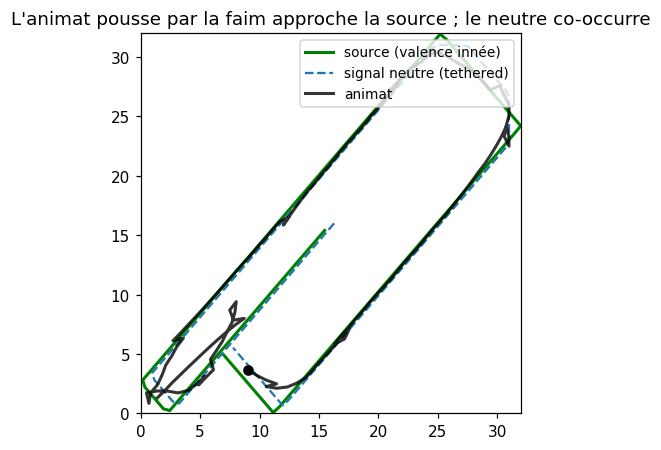

pi_neutre après co-occurrence = 1.000  (acquisition Rescorla-Wagner) ; contrôle hors-arène = 0.000


In [2]:
# Un episode court : source (balistique) + signal neutre tethered.
cfg = AnimatConfig(size=32)
animat = PregnanceAnimat(n_objects=3, config=cfg, rng=np.random.default_rng(0))
animat.set_intrinsic_valences({0: 1.0})   # objet 0 = source pertinente
trajs = _tethered_trajectories("balistique", 140, 32, np.random.default_rng(0),
                               n_objects=3, neutral_idx=1, control_idx=2)
_run_episode(animat, trajs, start=np.array([2.0, 2.0]))
trace = np.asarray(animat._pos_trace)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(trajs[0, :, 0], trajs[0, :, 1], "g-", lw=2, label="source (valence innée)")
ax.plot(trajs[1, :, 0], trajs[1, :, 1], "C0--", lw=1.5, label="signal neutre (tethered)")
ax.plot(trace[:, 0], trace[:, 1], "k-", lw=2, alpha=0.8, label="animat")
ax.scatter(*animat.pos, color="k", zorder=5)
ax.set_xlim(0, 32); ax.set_ylim(0, 32); ax.set_aspect("equal")
ax.set_title("L'animat pousse par la faim approche la source ; le neutre co-occurre")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()
print(f"pi_neutre après co-occurrence = {animat.lv.valence(1):.3f}  "
      f"(acquisition Rescorla-Wagner) ; contrôle hors-arène = {animat.lv.valence(2):.3f}")

## 2. Mesure 1 — $\hat p$ incarné : erreur d'anticipation vs baselines adverses

L'erreur d'anticipation 2D de $\hat p$ (MSE à l'horizon `lead`) contre 3 baselines du Cran A (persistance, moyenne mobile, AR(1)), par régime de source. **Sans complaisance** : $\hat p$ **gagne** en balistique (vitesse constante, extrapolation exacte) mais son erreur **explose** en erratique — les renversements trompent l'EMA-vitesse, et l'avantage sur la persistance fond (ratio 0.16 → 0.71 à graine 0). C'est le levier de la dissociation : $\hat p$ est fragile là où le conditionnement ne l'est pas.

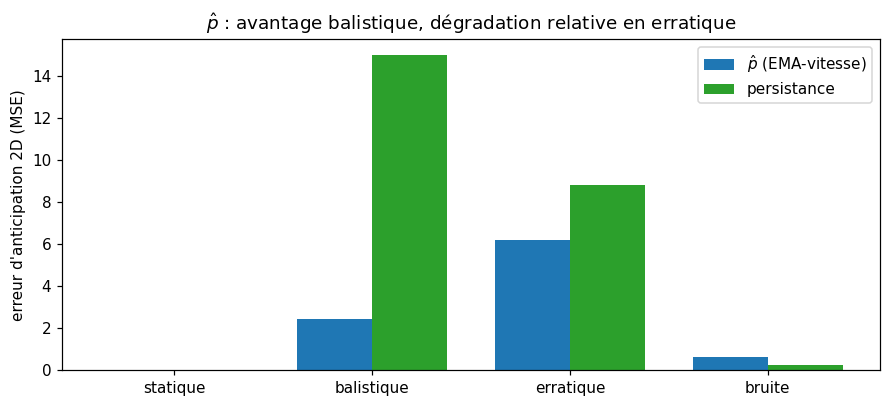

  statique    : p_hat=  0.03  pers=  0.01  ratio=2.61
  balistique  : p_hat=  2.43  pers= 15.00  ratio=0.16
  erratique   : p_hat=  6.20  pers=  8.79  ratio=0.71
  bruite      : p_hat=  0.64  pers=  0.24  ratio=2.60


In [3]:
sweep = phat_regime_sweep(seed=0)
regimes = ["statique", "balistique", "erratique", "bruite"]
errs = {r: sweep[r]["err_phat"] for r in regimes}
errs_p = {r: sweep[r]["err_persistence"] for r in regimes}

fig, ax = plt.subplots(figsize=(8.2, 3.8))
x = np.arange(len(regimes)); w = 0.38
ax.bar(x - w/2, [errs[r] for r in regimes], w, label=r"$\hat p$ (EMA-vitesse)", color="C0")
ax.bar(x + w/2, [errs_p[r] for r in regimes], w, label="persistance", color="C2")
ax.set_xticks(x); ax.set_xticklabels(regimes)
ax.set_ylabel("erreur d'anticipation 2D (MSE)")
ax.set_title(r"$\hat p$ : avantage balistique, dégradation relative en erratique")
ax.legend()
plt.tight_layout(); plt.show()
for r in regimes:
    print(f"  {r:11s} : p_hat={errs[r]:6.2f}  pers={errs_p[r]:6.2f}  "
          f"ratio={errs[r]/(errs_p[r]+1e-12):.2f}")

## 3. Mesure 2 — transfert incarné : le neutre devient-il *approché* seul ?

ICT-12b mesurait le transfert sur $\pi$ (scalaire). Ici on le mesure **comportementalement** : après conditionnement (neutre tethered à la source), le neutre est présenté **seul** (source retirée, faim élevée). L'animat l'approche-t-il **par lui-même** ? Un contrôle non-conditionné (présenté seul, $\pi = 0$) ne doit pas l'être — sinon c'est une fuite de l'inné vers tout.

In [4]:
rep = embodied_transfer_test(kind="balistique", seed=0)
print("Verdict TRANSFERT incarné :")
for k, v in rep.items():
    print(f"  {k:34} = {v:.4f}")
print(f"\n=> transferred = {rep['transferred']:.1f}  "
      f"(approche cond {rep['approach_fraction_conditioned']:.2f} vs contrôle "
      f"{rep['approach_fraction_control']:.2f}, gain +{rep['approach_gain']:.2f})")

Verdict TRANSFERT incarné :
  post_valence_neutral               = 1.0000
  control_valence_unconditioned      = 0.0000
  approach_fraction_conditioned      = 0.6250
  approach_fraction_control          = 0.1125
  approach_gain                      = 0.5125
  n_condition                        = 140.0000
  transferred                        = 1.0000

=> transferred = 1.0  (approche cond 0.62 vs contrôle 0.11, gain +0.51)


## 4. Mesure 3 — engagement d'action : un animat investi se replie sur sa cible

Un animat investi (forte $\pi$, faim élevée) collapse sa distribution d'actions sur sa cible : son **entropie d'action** chute sous le maximum $\ln(n_\text{actions})$ (uniforme = exploration pure). C'est la signature d'un **engagement** morphologique — l'envers de l'inhibition (strate 6, `ict.inhibited_action`). Le témoin est la borne supérieure $\ln(n_\text{actions})$, forme close.

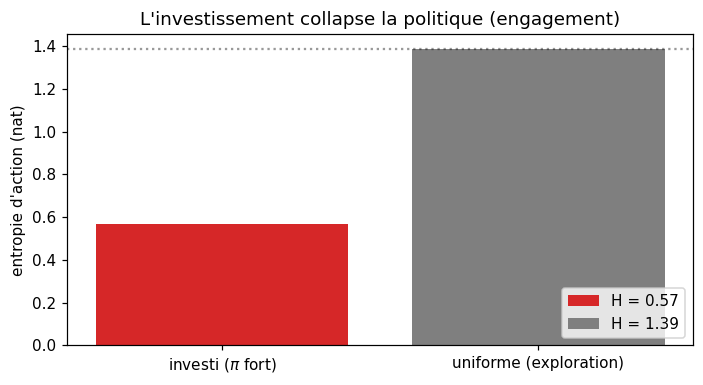

entropy_drop = 0.820  committed = 1.0  (pi_signal = 1.00)


In [5]:
rep3 = action_commitment_test(kind="balistique", seed=0)
H = rep3["action_entropy_invested"]; Hu = rep3["action_entropy_uniform"]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.bar([r"investi ($\pi$ fort)"], [H], color="C3", label=f"H = {H:.2f}")
ax.bar(["uniforme (exploration)"], [Hu], color="C7", label=f"H = {Hu:.2f}")
ax.axhline(Hu, ls=":", color="k", alpha=0.4)
ax.set_ylabel("entropie d'action (nat)")
ax.set_title("L'investissement collapse la politique (engagement)")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
print(f"entropy_drop = {rep3['entropy_drop']:.3f}  committed = {rep3['committed']:.1f}  "
      f"(pi_signal = {rep3['post_valence_signal']:.2f})")

## 5. Mesure 6 — réversibilité comportementale : l'approche acquise s'éteint

Miroir comportemental de la réversibilité de ICT-12b : après acquisition d'une approche du neutre (co-occurrence), on présente le signal **seul** prolongé (extinction). L'approche doit chuter — parce que $\pi$ s'éteint (Rescorla-Wagner : acquisition et extinction partagent la même règle). Ce qui s'apprend (approche) peut se désapprend.

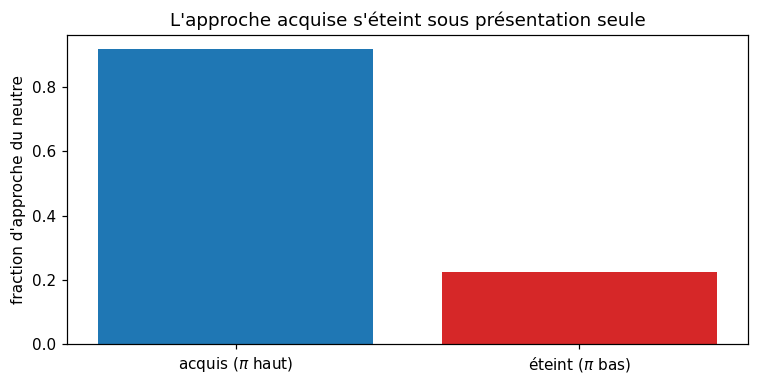

acquired_pi=1.000 -> extinguished_pi=0.0000  approach_drop=0.692  reversible=1.0


In [6]:
rep6 = behavioral_reversibility_test(kind="balistique", seed=0)
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.bar([r"acquis ($\pi$ haut)", r"éteint ($\pi$ bas)"],
       [rep6["approach_fraction_acquired"], rep6["approach_fraction_extinguished"]],
       color=["C0", "C3"])
ax.set_ylabel("fraction d'approche du neutre")
ax.set_title("L'approche acquise s'éteint sous présentation seule")
plt.tight_layout(); plt.show()
print(f"acquired_pi={rep6['acquired_valence']:.3f} -> extinguished_pi={rep6['extinguished_valence']:.4f}  "
      f"approach_drop={rep6['approach_drop']:.3f}  reversible={rep6['reversible']:.1f}")

## 6. La matrice de dissociation — la porte scientifique #7740

Quatre mesures qui bougent ensemble ne prouvent rien (elles pourraient n'être qu'un seul signal de poursuite). La validation est une **matrice de dissociation** : un régime où $\hat p$ est **fortement dégradé** MAIS transfert + engagement + réversibilité **tiennent**. Le régime `erratique` est ce levier : ses renversements de vitesse cassent l'estimation EMA (mesure 1), mais le conditionnement Rescorla-Wagner ne dépend que de la **co-occurrence** — pas de la prévisibilité. Donc $\hat p$ et $\pi$ se dissocient.

Une conclusion tirée d'un seul tirage ne vaut rien (#14439) : la matrice est donc évaluée sur **cinq graines** (0, 1, 7, 42, 99), et la grandeur qui porte la conclusion — le ratio erreur $\hat p$/persistance — est rapportée avec sa **dispersion inter-graines** (moyenne ± écart-type), verdicts comptés par graine.

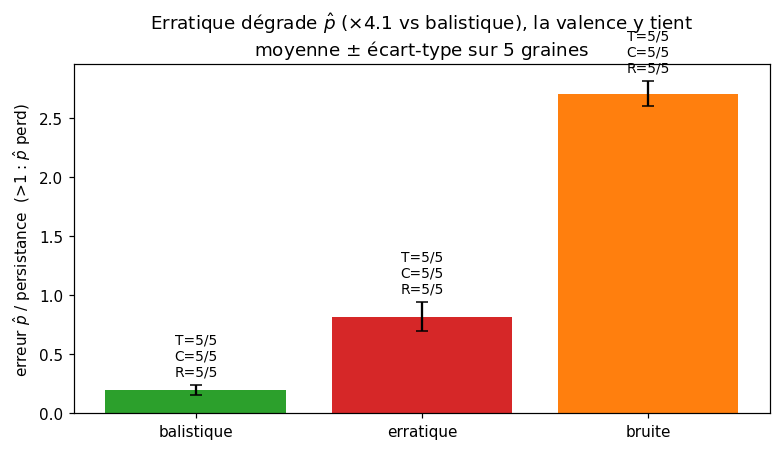

balistique  ratio p̂/pers par graine [0, 1, 7, 42, 99] : 0.16  0.23  0.14  0.23  0.23
balistique  moyenne ± écart-type = 0.197 ± 0.042   T=5/5  C=5/5  R=5/5
erratique   ratio p̂/pers par graine [0, 1, 7, 42, 99] : 0.71  0.95  0.94  0.80  0.69
erratique   moyenne ± écart-type = 0.816 ± 0.122   T=5/5  C=5/5  R=5/5
bruite      ratio p̂/pers par graine [0, 1, 7, 42, 99] : 2.60  2.87  2.65  2.65  2.75
bruite      moyenne ± écart-type = 2.702 ± 0.108   T=5/5  C=5/5  R=5/5

dissociation_observed = 5/5 graines -> dissociation robuste


In [7]:
# 5 graines : la conclusion ne doit pas dependre d'un tirage unique (#14439).
SEEDS = [0, 1, 7, 42, 99]
kinds = ["balistique", "erratique", "bruite"]
dms = {s: dissociation_matrix(seed=s) for s in SEEDS}

# Dispersion inter-graines du ratio erreur p_hat / persistance
ratio_mean = {k: np.mean([dms[s][k]["err_phat_vs_persistence"] for s in SEEDS])
              for k in kinds}
ratio_std = {k: np.std([dms[s][k]["err_phat_vs_persistence"] for s in SEEDS], ddof=1)
             for k in kinds}
tcr = {k: (int(sum(dms[s][k]["transferred"] for s in SEEDS)),
           int(sum(dms[s][k]["committed"] for s in SEEDS)),
           int(sum(dms[s][k]["reversible"] for s in SEEDS)))
       for k in kinds}

fig, ax = plt.subplots(figsize=(7.2, 4.2))
colors = ["C2", "C3", "C1"]
ax.bar(kinds, [ratio_mean[k] for k in kinds],
       yerr=[ratio_std[k] for k in kinds], capsize=4, color=colors)
ax.set_ylabel(r"erreur $\hat p$ / persistance  (>1 : $\hat p$ perd)")
ax.set_title(rf"Erratique dégrade $\hat p$ ($\times$"
             f"{ratio_mean['erratique'] / ratio_mean['balistique']:.1f} vs balistique), "
             r"la valence y tient" "\n"
             r"moyenne $\pm$ écart-type sur 5 graines")
for i, k in enumerate(kinds):
    T, C, R = tcr[k]
    ax.text(i, ratio_mean[k] + ratio_std[k] + 0.08,
            f"T={T}/5\nC={C}/5\nR={R}/5", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

for k in kinds:
    per_seed = "  ".join(f"{dms[s][k]['err_phat_vs_persistence']:.2f}" for s in SEEDS)
    T, C, R = tcr[k]
    print(f"{k:11s} ratio p̂/pers par graine [0, 1, 7, 42, 99] : {per_seed}")
    print(f"{k:11s} moyenne ± écart-type = {ratio_mean[k]:.3f} ± {ratio_std[k]:.3f}"
          f"   T={T}/5  C={C}/5  R={R}/5")
n_diss = int(sum(dms[s]["_verdict"]["dissociation_observed"] for s in SEEDS))
print(f"\ndissociation_observed = {n_diss}/{len(SEEDS)} graines -> "
      f"{'dissociation robuste' if n_diss == len(SEEDS) else 'dissociation NON robuste'}")

### Lecture du résultat : la dissociation survit aux cinq graines

**Sortie obtenue** : ratio $\hat p$/persistance, moyenne ± écart-type sur les graines 0, 1, 7, 42, 99 — balistique **0.20 ± 0.04**, erratique **0.82 ± 0.12**, bruité **2.70 ± 0.11** ; verdicts T/C/R à **5/5** dans les trois régimes ; `dissociation_observed` **5/5**.

| Régime | ratio $\hat p$/pers (moy ± std) | T / C / R | Lecture |
|---|---|---|---|
| balistique | 0.20 ± 0.04 | 5/5 · 5/5 · 5/5 | $\hat p$ extrapole proprement |
| erratique | 0.82 ± 0.12 | 5/5 · 5/5 · 5/5 | $\hat p$ dégradé (×4.1 vs balistique), valence intacte |
| bruité | 2.70 ± 0.11 | 5/5 · 5/5 · 5/5 | $\hat p$ perd contre la persistance, valence intacte |

**Points clés** :

1. **La conclusion n'est pas un artefact de graine** : le verdict de dissociation (erratique dégrade $\hat p$ relativement au balistique TANDIS QUE transfert + réversibilité tiennent) est observé sur chacune des cinq graines.
2. **Lecture honnête du ratio erratique** : 0.82 ± 0.12 reste *sous* 1 — en erratique, $\hat p$ bat encore marginalement la persistance (valeurs par graine de 0.69 à 0.95, jamais au-dessus). La dégradation est *relative* (×4.1 vs balistique), pas un effondrement absolu. Le dépassement de la persistance (2.70 ± 0.11) se produit dans le régime **bruité** — où la valence tient elle aussi (5/5) : la dissociation est robuste tant sous dégradation relative qu'en échec absolu de $\hat p$.
3. **Dispersion modérée** : l'écart-type vaut ~15 % de la moyenne en erratique, ~21 % en balistique ; l'ordre des régimes (balistique < erratique < bruité) est stable sur les cinq graines — le classement ne repose pas sur un tirage chanceux.

## 7. Trois lecteurs orthogonaux de $\hat q$ — erreur, énergie libre, information

La matrice de dissociation (§6) opposait $\hat p$ à la valence $\pi$. On change de grandeur : $\hat q$ — la *prédiction lead-ahead* de l'animat (`prediction_trace()`) — admet **trois lecteurs distincts**, chacun avec un comportement de régime propre :

- **Erreur de point (MSE)** — mesure 1 : $\hat q$ loin de l'observation en distance.
- **Énergie libre adaptive (FE)** — mesure 4 : la surprise *renormalisée par la variance attendue*. En précision fixe, ce n'est qu'un habillage du MSE (gate 1) ; en précision adaptive, elle *amortit* l'explosion erratique (gate 2).
- **Information prédictive (MI)** — mesure 5 : $I(\hat q;o)$ en bits, *combien $\hat q$ réduit l'incertitude* sur l'observation.

Ces bancs sont **orthogonaux** à la dissociation $\hat p/\pi$ : ils opposent des lecteurs de $\hat q$ lui-même. Leur conclusion : la représentation prédictive $q$ n'est pas réductible à un seul scalaire d'erreur.

### 7.1 Énergie libre adaptive (mesure 4) — la surprise renormalisée

`free_energy_profile_test` calcule la surprise lead-ahead de $\hat q$ en précision **fixe** puis **adaptive** (EMA causale des erreurs passées, plancher scale-aware à 5 % de la variance globale), confrontée au MSE, à travers les régimes balistique / erratique.

Deux verdicts falsifiables :

- `fe_fixed_monotone_with_mse` : en précision fixe, FE et MSE rangent les régimes pareil (FE = habillage du MSE, gate 1).
- `fe_adaptive_amortizes_mse` : la précision adaptive amortit l'explosion erratique (ratio FE-adaptive err/bal *inférieur* au ratio MSE, gate 2).

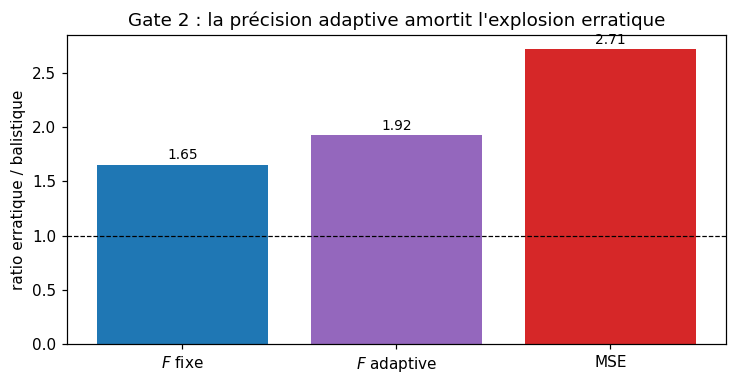

fe_fixed_monotone_with_mse = 1  (F fixe range comme le MSE : gate 1)
fe_adaptive_amortizes_mse  = 1  (F-adaptive 1.92 < MSE 2.71 : gate 2)


In [8]:
fe4 = free_energy_profile_test(seed=0)
labels = [r"$F$ fixe", r"$F$ adaptive", r"MSE"]
ratios = [fe4["F_fixed_ratio_err_over_bal"],
          fe4["F_adaptive_ratio_err_over_bal"],
          fe4["mse_ratio_err_over_bal"]]
colors = ["C0", "C4", "C3"]
fig, ax = plt.subplots(figsize=(6.8, 3.6))
ax.bar(labels, ratios, color=colors)
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_ylabel(r"ratio erratique / balistique")
ax.set_title(r"Gate 2 : la précision adaptive amortit l'explosion erratique")
for i, r in enumerate(ratios):
    ax.text(i, r + 0.05, f"{r:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print(f"fe_fixed_monotone_with_mse = {fe4['fe_fixed_monotone_with_mse']:.0f}  "
      f"(F fixe range comme le MSE : gate 1)")
print(f"fe_adaptive_amortizes_mse  = {fe4['fe_adaptive_amortizes_mse']:.0f}  "
      f"(F-adaptive {fe4['F_adaptive_ratio_err_over_bal']:.2f} < "
      f"MSE {fe4['mse_ratio_err_over_bal']:.2f} : gate 2)")

### 7.2 Information prédictive (mesure 5) — $I(\hat q;o)$ vs MSE

`predictive_information_regime_contrast` mesure l'information mutuelle (en bits) entre $\hat q[t]$ et $o[t+\mathrm{lead}]$ — projettée sur $x$, discrétisée en quantiles — confrontée au MSE. Verdict falsifiable :

- `mi_anticorrelated_with_mse` : sous erratique, le MSE *explose* (ratio > 1) mais la MI *chute* (ratio < 1). Les deux lecteurs vont en sens inverse — la cible erratique est *génuinement moins prévisible* (plafond épistémique, pas un défaut d'estimateur).

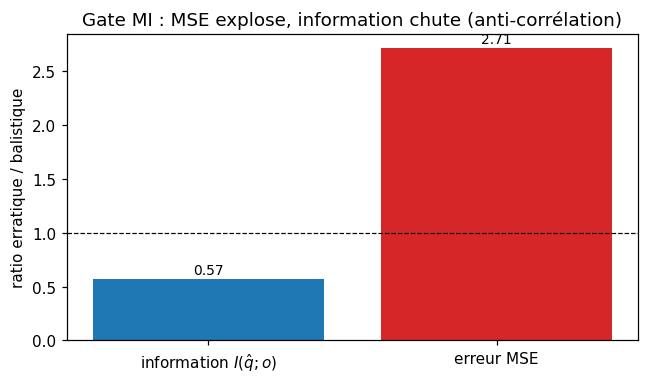

mi_anticorrelated_with_mse = 1  (MI 0.57 chute, MSE 2.71 monte)


In [9]:
mi5 = predictive_information_regime_contrast(seed=0)
labels = [r"information $I(\hat q;o)$", r"erreur MSE"]
ratios = [mi5["MI_ratio_err_over_bal"], mi5["MSE_ratio_err_over_bal"]]
colors = ["C0", "C3"]
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.bar(labels, ratios, color=colors)
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_ylabel(r"ratio erratique / balistique")
ax.set_title(r"Gate MI : MSE explose, information chute (anti-corrélation)")
for i, r in enumerate(ratios):
    ax.text(i, r + 0.05, f"{r:.2f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print(f"mi_anticorrelated_with_mse = {mi5['mi_anticorrelated_with_mse']:.0f}  "
      f"(MI {mi5['MI_ratio_err_over_bal']:.2f} chute, "
      f"MSE {mi5['MSE_ratio_err_over_bal']:.2f} monte)")

### 7.3 Synthèse — $\hat q$ n'est pas un scalaire

Trois lecteurs, trois comportements de régime distincts : le MSE *explose* sous erratique, la FE-adaptive l'*amortit*, la MI *chute* (plafond épistémique). Aucun scalaire unique ne résume la représentation prédictive $q$ — c'est la contribution propre des mesures 4 et 5 au tableau 4-objets $(s, q, \pi, W)$, et l'envers exact de la dissociation $\hat p/\pi$ du §6 (qui séparait deux grandeurs qui *tiennent* ; ici on montre que $q$ lui-même se décompose en lecteurs hétérogènes).

## 8. Exercices

Les exercices étendent l'animat sur des leviers non couverts (second ordre, rôle du drive, abstention). *Conventions* : `print "à compléter"`, pas de `raise`.

### Exercice 1 — Conditionnement de second ordre

Un signal $B$ neutre co-occurre avec un signal $A$ **déjà conditionné** (pas avec la source directement). $B$ devient-il attractif ? Modifiez `_tethered_trajectories` pour que $B$ suive $A$ (lui-même tethered à la source), et mesurez `embodied_transfer_test` sur $B$.

In [10]:
# Exercice 1 : conditionnement de second ordre (B suit A suit source).
# TODO étudiant :
#  1. Construire des trajectoires où A est tethered à la source, B tethered à A.
#  2. Conditionner, puis tester l'approche de B seul.
print("Exercice 1 à compléter : transfert de second ordre B -> A -> source.")

Exercice 1 à compléter : transfert de second ordre B -> A -> source.


### Exercice 2 — Sensibilité au drive `hunger`

La politique pondère la salience par `hunger`. Que se passe-t-il si `hunger_rate` est divisé par 10 (animat rarement affamé) ? Le verdict `transferred` survive-t-il ? Écrivez une boucle sur `AnimatConfig(hunger_rate=...)` et tracez `approach_gain` vs `hunger_rate`.

In [11]:
# Exercice 2 : sweeper hunger_rate, tracer approach_gain.
# TODO étudiant :
#  1. for hr in [0.001, 0.005, 0.015, 0.03]: cfg = AnimatConfig(hunger_rate=hr) ...
#  2. Collecter approach_gain, tracer vs hr.
print("Exercice 2 à compléter : approach_gain vs hunger_rate.")

Exercice 2 à compléter : approach_gain vs hunger_rate.


### Exercice 3 — Abstention : un signal à valence négative

Toutes les sources ici sont attractives (`intrinsic_valence` > 0). Ajoutez un objet **répulsif** (`intrinsic_valence < 0`, par exemple un prédateur). L'animat doit-il l'éviter ? Proposez une mesure `avoidance_fraction` symétrique à `approach_fraction`, et vérifiez qu'elle est haute pour le répulsif.

In [12]:
# Exercice 3 : valence négative + avoidance_fraction.
# TODO étudiant :
#  1. ObjectSpec(idx=3, intrinsic_valence=-1.0) (prédateur).
#  2. Mesurer avoidance = 1 - approach_fraction(pred_idx) ; vérifier qu'elle est haute.
print("Exercice 3 à compléter : abstention face à un signal répulsif.")

Exercice 3 à compléter : abstention face à un signal répulsif.


## Conclusion

L'incarnation ne recolle pas valence et prédiction — elle les **dissocie** plus nettement encore. Sur le régime erratique, le modèle interne $\hat p$ est fortement dégradé (ratio erreur vs persistance ×4.1 relativement au balistique) mais l'investissement thomien — la valence apprise $\pi$, transférée par co-occurrence, réversible par extinction, mobilisant l'action — tient. C'est la réponse à la question #7740 : **prégnance et représentation sont deux grandeurs distinctes**, même chez un animat incarné.

Cette dissociation **survit à l'analyse multi-graines** : sur les cinq graines 0, 1, 7, 42, 99, le verdict `dissociation_observed` tient **5/5**, l'ordre des régimes (balistique < erratique < bruité) est stable, et transfert/engagement/réversibilité sont 5/5 partout. Lecture honnête de la dispersion : en erratique, le ratio $\hat p$/persistance vaut **0.82 ± 0.12** — toujours *sous* 1, c'est-à-dire que $\hat p$ bat encore marginalement la persistance (valeurs par graine de 0.69 à 0.95) ; la dégradation est *relative* au balistique (0.20 ± 0.04), pas un effondrement absolu. Le dépassement de la persistance appartient au régime **bruité** (2.70 ± 0.11) — où la valence tient elle aussi (5/5) : la dissociation est robuste tant sous dégradation relative qu'en échec absolu de $\hat p$.

*Portée honnête* : ce notebook couvre les **six mesures** 1, 2, 3, 4, 5, 6 + la matrice de dissociation. Les mesures 4 (énergie-libre adaptive) et 5 (information prédictive), différées en PR-A comme recherche, sont désormais livrées (§7) : `free_energy` mode `fixed` n'est qu'un habillage du MSE (gate 1), mais la précision *adaptive* amortit l'explosion erratique (gate 2), et l'information mutuelle $I(\hat q;o)$ y est *anti-corrélée* au MSE (plafond épistémique). Trois lecteurs orthogonaux de $\hat q$.

> **Voir aussi.** [ICT-12](ICT-12-ValenceFieldsAndAnimats.ipynb) (valence programmée, champ spatial), [ICT-12b](ICT-12b-LearnedValence.ipynb) (valence apprise désincarnée, le banc algorithmique que cet animat incarne), [ICT-0-Framing](ICT-0-Framing.md) (jambe C1, #7740).